In [ ]:
from google.colab import files
import numpy as np
import glob, json, os
import pandas as pd
import tensorflow as tf,keras
import matplotlib.pyplot as plt
import joblib
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression,SelectFromModel, RFE
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor,GradientBoostingRegressor, AdaBoostRegressor
from scipy.stats import randint, uniform, loguniform, uniform
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.linear_model import Ridge, ElasticNet, LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras import layers
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import warnings

In [ ]:
#Caricamento Dataset
uploaded = files.upload()

Saving blogfeedback.zip to blogfeedback.zip


In [ ]:
import zipfile
os.makedirs("blogfeedback", exist_ok=True)

In [ ]:
# Estrai ZIP
for f in uploaded.keys():
    if f.endswith(".zip"):
        with zipfile.ZipFile(f, 'r') as zip_ref:
            zip_ref.extractall("blogfeedback")

print("File in blogfeedback:")
print(os.listdir("blogfeedback"))

File in blogfeedback:
['blogData_test-2012.03.04.00_00.csv', 'blogData_test-2012.03.14.00_00.csv', 'blogData_test-2012.03.30.01_00.csv', 'blogData_test-2012.02.12.00_00.csv', 'blogData_test-2012.02.03.00_00.csv', 'blogData_test-2012.02.28.00_00.csv', 'blogData_test-2012.02.08.00_00.csv', 'blogData_test-2012.02.27.00_00.csv', 'blogData_test-2012.02.25.00_00.csv', 'blogData_test-2012.03.05.00_00.csv', 'blogData_test-2012.02.23.00_00.csv', 'blogData_test-2012.02.07.00_00.csv', 'blogData_test-2012.03.13.00_00.csv', 'blogData_test-2012.02.21.00_00.csv', 'blogData_test-2012.03.07.00_00.csv', 'blogData_test-2012.03.23.00_00.csv', 'blogData_test-2012.03.10.00_00.csv', 'blogData_test-2012.02.17.00_00.csv', 'blogData_test-2012.03.09.00_00.csv', 'blogData_test-2012.03.27.01_00.csv', 'blogData_test-2012.03.20.00_00.csv', 'blogData_test-2012.03.26.01_00.csv', 'blogData_test-2012.02.15.00_00.csv', 'blogData_test-2012.03.15.00_00.csv', 'blogData_test-2012.02.20.00_00.csv', 'blogData_train.csv', 'blog

In [ ]:
os.listdir()


['.config', 'blogfeedback', 'blogfeedback.zip', 'sample_data']

In [ ]:
for f in os.listdir():
    if f.startswith("blogData_"):
        os.rename(f, os.path.join("blogfeedback", f))


In [ ]:
# Trova tutti i csv dentro la cartella estratta
csv_files = glob.glob("blogfeedback/*.csv")
print("Trovati:", len(csv_files), "file")

Trovati: 61 file


In [ ]:
# Caricamento train
train_file = "blogfeedback/blogData_train.csv"
train_df = pd.read_csv(train_file, header=None)

In [ ]:
# Caricamento test
test_files = sorted(glob.glob("blogfeedback/blogData_test-*.csv"))


In [ ]:
# Rimozione duplicati completi nel train (features + target)
train_df = train_df.drop_duplicates()
print("Shape dopo drop_duplicates:", train_df.shape)

Shape dopo drop_duplicates: (49203, 281)


In [ ]:
# 3) Separazione X e y
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

In [ ]:
# Rinomina colonne train
feature_names = [f"f{i}" for i in range(X_train.shape[1])]
X_train.columns = feature_names
y_train.name = "comments_24h"

In [ ]:
# Caricamento 60 file test
for f in test_files:
    X_test = pd.read_csv(f, header=None).iloc[:, :-1]
    y_test = pd.read_csv(f, header=None).iloc[:, -1]

In [ ]:
# Rinomina colonne Test
X_test.columns = feature_names
y_test.name = "comments_24h"

Prima esplorazione del Dataset

In [ ]:
#Controllo dei primi 5 record train
print("Prime 5 righe:")
print(train_df.head())

Prime 5 righe:
        0          1    2      3     4         5         6    7      8    9    \
0  40.30467  53.845657  0.0  401.0  15.0  15.52416  32.44188  0.0  377.0  3.0   
1  40.30467  53.845657  0.0  401.0  15.0  15.52416  32.44188  0.0  377.0  3.0   
4  40.30467  53.845657  0.0  401.0  15.0  15.52416  32.44188  0.0  377.0  3.0   
5  40.30467  53.845657  0.0  401.0  15.0  15.52416  32.44188  0.0  377.0  3.0   
8  40.30467  53.845657  0.0  401.0  15.0  15.52416  32.44188  0.0  377.0  3.0   

   ...  271  272  273  274  275  276  277  278  279   280  
0  ...  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   1.0  
1  ...  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  
4  ...  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  27.0  
5  ...  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  
8  ...  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   9.0  

[5 rows x 281 columns]


In [ ]:
# Statistiche rapide
print("\nStatistiche descrittive delle feature:")
print(X_train.describe())

print("\nStatistiche del target:")
print(y_train.describe())


Statistiche descrittive delle feature:
                 f0            f1            f2            f3            f4  \
count  49203.000000  49203.000000  49203.000000  49203.000000  49203.000000   
mean      38.091771     45.066725      0.371868    324.455907     24.025588   
std       80.520645     62.820890      7.057835    440.723194     71.112351   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        2.114014      4.766201      0.000000     21.000000      0.000000   
50%       10.630660     19.170923      0.000000    150.000000      4.000000   
75%       39.644764     75.590485      0.000000    438.000000     14.000000   
max     1122.666600    559.432600    726.000000   2044.000000   1314.000000   

                 f5            f6            f7            f8            f9  \
count  49203.000000  49203.000000  49203.000000  49203.000000  49203.000000   
mean      14.805704     27.219151      0.002906    251.210780      5.719966   
std       3

In [ ]:
print("Feature shape:", X_train.shape)

Feature shape: (49203, 280)


In [ ]:
# Rimozione duplicati nel train
duplicates = X_train.duplicated()
print("Duplicati nel train:", duplicates.sum())

X_train = X_train[~duplicates]
y_train = y_train[~duplicates]

Duplicati nel train: 409


SALVAGGIO-

In [ ]:
def evaluate_model_filewise(model, model_name):
    all_y_true = []
    all_y_pred = []

    print(f"\n===== VALUTAZIONE {model_name} =====")
    # Valutazione modello file per file
    for f in test_files:
        df_test = pd.read_csv(f, header=None)
        # Separazione feature e target
        X_test = df_test.iloc[:, :-1]
        y_test = df_test.iloc[:, -1]
        X_test.columns = feature_names
        y_test.name = "comments_24h"

        y_pred = model.predict(X_test)
        y_pred = np.maximum(y_pred, 0)

        # Metriche per file
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"{os.path.basename(f)} | MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")

        all_y_true.extend(y_test.values)
        all_y_pred.extend(y_pred)

    # Metriche globali
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    mae_global = mean_absolute_error(all_y_true, all_y_pred)
    rmse_global = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
    r2_global = r2_score(all_y_true, all_y_pred)

    print(f"\n{model_name} – METRICHE GLOBALI")
    print(f"MAE={mae_global:.3f}")
    print(f"RMSE={rmse_global:.3f}")
    print(f"R2={r2_global:.3f}")

    return mae_global, rmse_global, r2_global, all_y_true, all_y_pred

In [ ]:
# =========================
# VALUTAZIONE FILE PER FILE
# =========================
mae_bag, rmse_bag, r2_bag = evaluate_model_filewise(
    grid_bagging.best_estimator_, "Bagging (Random Forest)"
)

mae_boost, rmse_boost, r2_boost = evaluate_model_filewise(
    grid_boosting.best_estimator_, "Boosting (Gradient Boosting)"
)


===== VALUTAZIONE Bagging (Random Forest) =====
blogData_test-2012.02.01.00_00.csv | MAE=5.516 | RMSE=17.407 | R2=0.810
blogData_test-2012.02.02.00_00.csv | MAE=4.412 | RMSE=17.164 | R2=0.697
blogData_test-2012.02.03.00_00.csv | MAE=5.131 | RMSE=28.896 | R2=0.515
blogData_test-2012.02.04.00_00.csv | MAE=3.304 | RMSE=8.833 | R2=-0.024
blogData_test-2012.02.05.00_00.csv | MAE=3.117 | RMSE=13.140 | R2=0.830
blogData_test-2012.02.06.00_00.csv | MAE=4.526 | RMSE=14.981 | R2=0.669
blogData_test-2012.02.07.00_00.csv | MAE=6.476 | RMSE=24.339 | R2=-2.568
blogData_test-2012.02.08.00_00.csv | MAE=6.376 | RMSE=27.631 | R2=0.451
blogData_test-2012.02.09.00_00.csv | MAE=4.568 | RMSE=21.038 | R2=0.575
blogData_test-2012.02.10.00_00.csv | MAE=4.306 | RMSE=18.099 | R2=0.593
blogData_test-2012.02.11.00_00.csv | MAE=3.147 | RMSE=9.721 | R2=-4.512
blogData_test-2012.02.12.00_00.csv | MAE=1.478 | RMSE=5.636 | R2=-4.248
blogData_test-2012.02.13.00_00.csv | MAE=3.943 | RMSE=16.938 | R2=-0.041
blogData_test

In [ ]:
# =========================
# BAGGING - Random Forest
# =========================

# Pipeline con feature selection e Random Forest
pipe_bagging = Pipeline([
    ("selector", SelectKBest(score_func=f_regression)),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=42, n_jobs=2),
        func=np.log1p,      # trasformazione log del target
        inverse_func=np.expm1 # trasformazione inversa
    ))
])

# Griglia di iperparametri
param_grid_bagging = {
    "selector__k": [50, 100],
    "model__regressor__n_estimators": [100],
    "model__regressor__max_depth": [None, 40],
    "model__regressor__max_features": ["sqrt"]
}

# Grid Search con cross-validation
grid_bagging = GridSearchCV(
    pipe_bagging,
    param_grid=param_grid_bagging,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=0
)

grid_bagging.fit(X_train, y_train)
# Predizione sul test set
yy_pred_bagging = grid_bagging.best_estimator_.predict(X_test)

print("===== BAGGING (Random Forest) =====")
print("Best parameters:", grid_bagging.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_bagging))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_bagging)))
print("R2:", r2_score(y_test, y_pred_bagging))


===== BAGGING (Random Forest) =====
Best parameters: {'model__regressor__max_depth': None, 'model__regressor__max_features': 'sqrt', 'model__regressor__n_estimators': 100, 'selector__k': 50}
MAE: 8.129532519301097
RMSE: 29.955110758290466
R2: 0.6057943861845843


In [ ]:
# =========================
# BOOSTING - Gradient Boosting
# =========================

# Pipeline con feature selection e Gradient Boosting
pipe_boosting = Pipeline([
    ("selector", SelectKBest(score_func=f_regression)),
    ("model", TransformedTargetRegressor(
        regressor=GradientBoostingRegressor(random_state=42),
        func=np.log1p,        # trasformazione log del target
        inverse_func=np.expm1 # trasformazione inversa
    ))
])

# Griglia di iperparametri
param_grid_boosting = {
    "selector__k": [50, 100],
    "model__regressor__n_estimators": [100],
    "model__regressor__learning_rate": [0.1],
    "model__regressor__max_depth": [3]
}

# Grid Search con cross-validation
grid_boosting = GridSearchCV(
    pipe_boosting,
    param_grid=param_grid_boosting,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=0
)

grid_boosting.fit(X_train, y_train)
# Predizione sul test set
y_pred_boosting = grid_boosting.best_estimator_.predict(X_test)

print("===== BOOSTING (Gradient Boosting) =====")
print("Best parameters:", grid_boosting.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_boosting))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_boosting)))
print("R2:", r2_score(y_test, y_pred_boosting))


===== BOOSTING (Gradient Boosting) =====
Best parameters: {'model__regressor__learning_rate': 0.1, 'model__regressor__max_depth': 3, 'model__regressor__n_estimators': 100, 'selector__k': 50}
MAE: 5.101013842456306
RMSE: 23.131461393618938
R2: 0.7649354771947645


In [ ]:
# =========================
# CONFRONTO MODELLI
# =========================

# Calcolo le metriche per il modello Bagging (Random Forest)
mae_bag = mean_absolute_error(y_test, y_pred_bagging)          # Errore assoluto medio
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bagging)) # Radice dell'errore quadratico medio
r2_bag = r2_score(y_test, y_pred_bagging)                     # Coefficiente di determinazione R²

# Calcolo le metriche per il modello Boosting (Gradient Boosting)
mae_boost = mean_absolute_error(y_test, y_pred_boosting)          # Errore assoluto medio
rmse_boost = np.sqrt(mean_squared_error(y_test, y_pred_boosting)) # Radice dell'errore quadratico medio
r2_boost = r2_score(y_test, y_pred_boosting)                     # Coefficiente di determinazione R²

# Creo un DataFrame per confrontare i due modelli
results = pd.DataFrame({
    "Model": ["Bagging (Random Forest)", "Boosting (Gradient Boosting)"],  # Nomi dei modelli
    "MAE": [mae_bag, mae_boost],                                           # Colonna MAE
    "RMSE": [rmse_bag, rmse_boost],                                        # Colonna RMSE
    "R2": [r2_bag, r2_boost]                                               # Colonna R²
})

# Stampo i risultati in tabella
print(results)

                          Model       MAE       RMSE        R2
0       Bagging (Random Forest)  8.129533  29.955111  0.605794
1  Boosting (Gradient Boosting)  5.101014  23.131461  0.764935


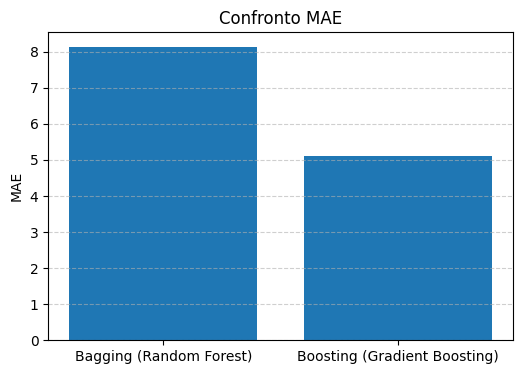

In [ ]:
# =========================
# Grafico MAE
# =========================
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MAE"])
plt.title("Confronto MAE")
plt.ylabel("MAE")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


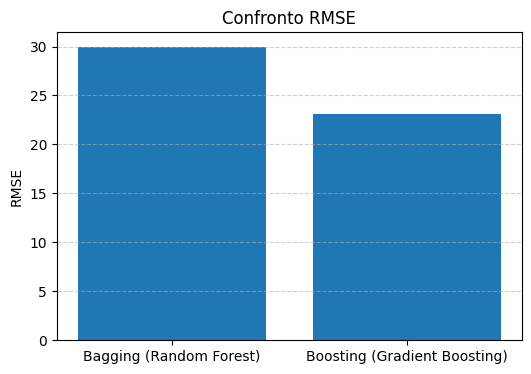

In [ ]:
# =========================
# Grafico RMSE
# =========================
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("Confronto RMSE")
plt.ylabel("RMSE")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


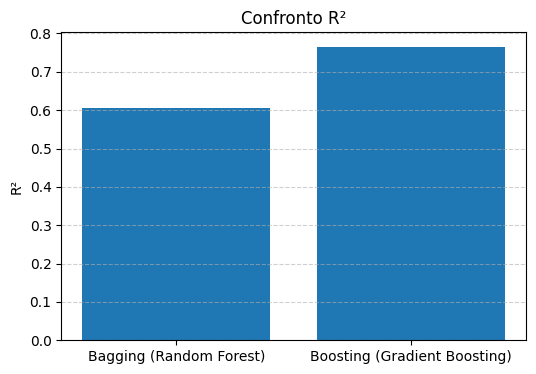

In [ ]:
# =========================
# Grafico R²
# =========================
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["R2"])
plt.title("Confronto R²")
plt.ylabel("R²")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


                          Model       MAE       RMSE        R2
0       Bagging (Random Forest)  8.129533  29.955111  0.605794
1  Boosting (Gradient Boosting)  5.101014  23.131461  0.764935


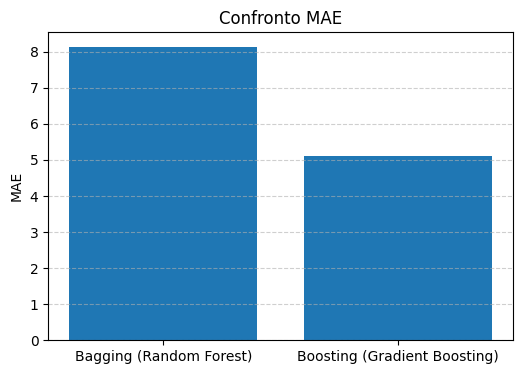

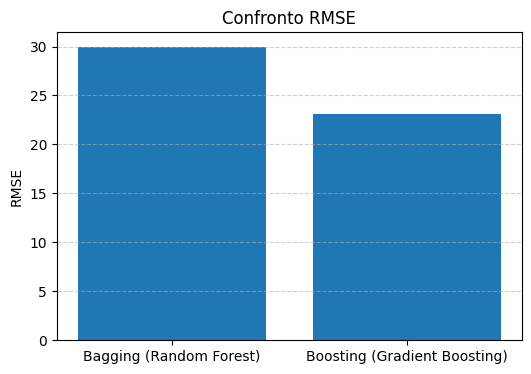

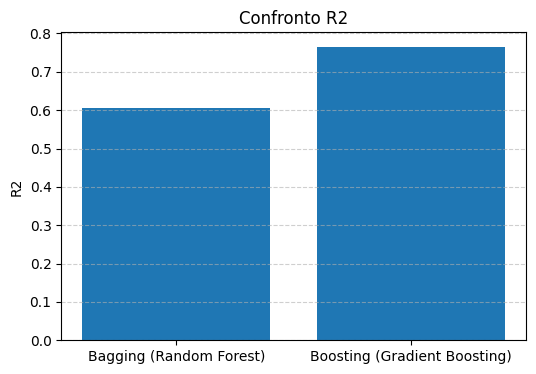

In [ ]:
# =========================
# CONFRONTO E GRAFICI
# =========================
results = pd.DataFrame({
    "Model": ["Bagging (Random Forest)", "Boosting (Gradient Boosting)"],
    "MAE": [mae_bag, mae_boost],
    "RMSE": [rmse_bag, rmse_boost],
    "R2": [r2_bag, r2_boost]
})

print(results)

# Grafici metriche
for metric in ["MAE", "RMSE", "R2"]:
    plt.figure(figsize=(6,4))
    plt.bar(results["Model"], results[metric])
    plt.title(f"Confronto {metric}")
    plt.ylabel(metric)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

GULINO

DECISION TREE REGRESSOR

In [ ]:

#Pipeline con scaler, model e feature selection
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(f_regression, k=50)), # feature selection
    ("tree", DecisionTreeRegressor(random_state=42))
])

#Ottimizzazione iperparametrica con GridSearchCV
param_grid = {
    "tree__max_depth": [5, 10, 15, 20, None],
    "tree__min_samples_leaf": [10, 50, 100, 300],
    "tree__min_samples_split": [20, 50, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train) #addestro il mio modello

best_tree = grid.best_estimator_

print("Migliori iperparametri:", grid.best_params_) #ricavo i migliori iperparametri


Migliori iperparametri: {'tree__max_depth': 15, 'tree__min_samples_leaf': 50, 'tree__min_samples_split': 20}


In [ ]:
#valutazione test per test rispettando split temporale richiesto dal dataset
mae_boost, rmse_boost, r2_boost, all_y_true, all_y_pred = evaluate_model_filewise(
    best_tree, "Decision Tree"
)


===== VALUTAZIONE Decision Tree =====
blogData_test-2012.02.01.00_00.csv | MAE=6.589 | RMSE=24.306 | R2=0.630
blogData_test-2012.02.02.00_00.csv | MAE=4.303 | RMSE=15.125 | R2=0.764
blogData_test-2012.02.03.00_00.csv | MAE=4.548 | RMSE=28.545 | R2=0.527
blogData_test-2012.02.04.00_00.csv | MAE=2.610 | RMSE=6.359 | R2=0.469
blogData_test-2012.02.05.00_00.csv | MAE=2.901 | RMSE=11.948 | R2=0.860
blogData_test-2012.02.06.00_00.csv | MAE=4.186 | RMSE=13.902 | R2=0.715
blogData_test-2012.02.07.00_00.csv | MAE=6.598 | RMSE=31.903 | R2=-5.130
blogData_test-2012.02.08.00_00.csv | MAE=5.307 | RMSE=26.289 | R2=0.503
blogData_test-2012.02.09.00_00.csv | MAE=4.068 | RMSE=21.652 | R2=0.550
blogData_test-2012.02.10.00_00.csv | MAE=3.996 | RMSE=14.143 | R2=0.752
blogData_test-2012.02.11.00_00.csv | MAE=3.109 | RMSE=9.608 | R2=-4.384
blogData_test-2012.02.12.00_00.csv | MAE=1.275 | RMSE=3.713 | R2=-1.277
blogData_test-2012.02.13.00_00.csv | MAE=4.361 | RMSE=17.883 | R2=-0.160
blogData_test-2012.02.14

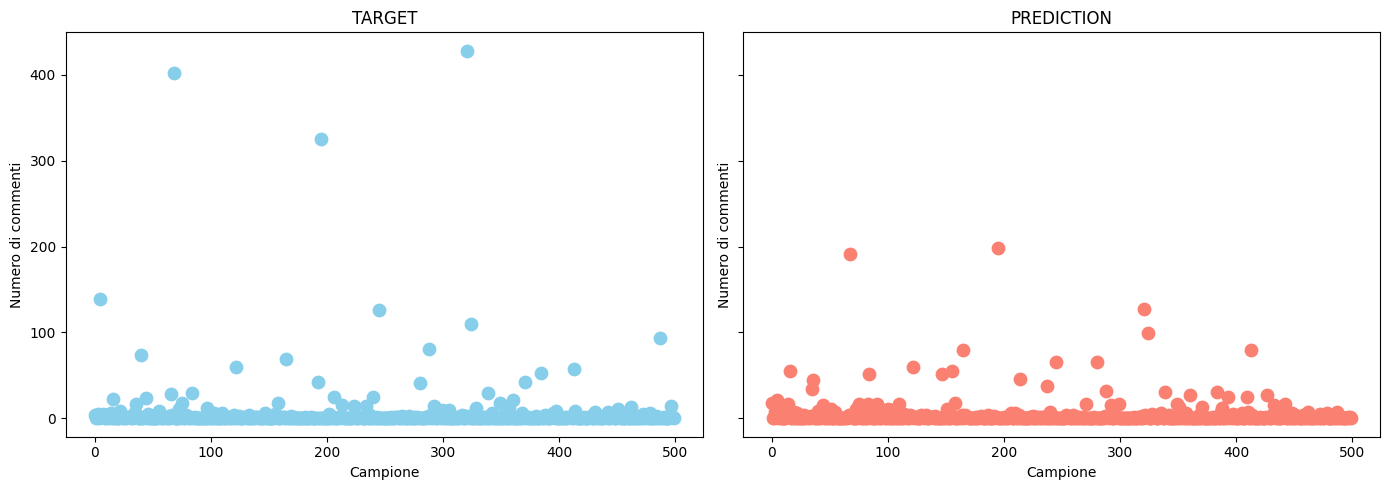

In [ ]:
# Seleziono un campione per il grafico (primi 500 valori)
n_plot = 500
y_true_plot = all_y_true[:n_plot]
y_pred_plot = all_y_pred[:n_plot]
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Grafico dei valori reali
axs[0].scatter(range(n_plot), y_true_plot, color='skyblue', s=80)
axs[0].set_title("TARGET")
axs[0].set_xlabel("Campione")
axs[0].set_ylabel("Numero di commenti")


# Grafico dei valori predetti dal Decision Tree
axs[1].scatter(range(n_plot), y_pred_plot, color='salmon', s=80)
axs[1].set_title("PREDICTION")
axs[1].set_xlabel("Campione")
axs[1].set_ylabel("Numero di commenti")


plt.tight_layout()
plt.show()


KNN

In [ ]:
# Log-transform sul target
y_train_log = np.log1p(y_train)


# Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', RobustScaler(quantile_range=(10,90))),
    ('selector', SelectKBest(score_func=f_regression, k=80)),  # seleziona le 50 migliori feature
    ('knn', KNeighborsRegressor())
])

# Grid degli iperparametri
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 10, 15, 20, 25],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

#ottimizzazione iperparametrica
grid_knn = GridSearchCV(
    pipe_knn,
    param_grid,
    cv=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1

    )

grid_knn.fit(X_train, y_train_log)  # addestro su log(y) per far gestire meglio asimmetrie

best_knn = grid_knn.best_estimator_
print("Migliori iperparametri KNN:", grid_knn.best_params_)


Migliori iperparametri KNN: {'knn__n_neighbors': 25, 'knn__p': 2, 'knn__weights': 'distance'}


In [ ]:
# Valutazione su test files con back-transform
all_y_true = []
all_y_pred = []

test_files = sorted(glob.glob("blogfeedback/blogData_test-*.csv"))

for f in test_files:
    X_test = pd.read_csv(f, header=None).iloc[:, :-1]
    y_test = pd.read_csv(f, header=None).iloc[:, -1]

    X_test.columns = feature_names
    y_test.name = "comments_24h"

    # Predizione log + back-transform
    y_pred_log = best_knn.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    # Evita valori negativi
    y_pred = np.maximum(y_pred, 0)

    all_y_true.extend(y_test.values)
    all_y_pred.extend(y_pred)

    # Metriche per file rispettando split temporale richiesto dal dataset
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"KNN {f.split('/')[-1]} MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")


# Metriche globali
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

mae_global = mean_absolute_error(all_y_true, all_y_pred)
rmse_global = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
r2_global = r2_score(all_y_true, all_y_pred)

print("\nKNN METRICHE GLOBALI SU TUTTI I TEST FILE")
print(f"MAE={mae_global:.3f} | RMSE={rmse_global:.3f} | R2={r2_global:.3f}")

KNN blogData_test-2012.02.01.00_00.csv MAE=5.377 | RMSE=23.119 | R2=0.665
KNN blogData_test-2012.02.02.00_00.csv MAE=5.216 | RMSE=25.155 | R2=0.349
KNN blogData_test-2012.02.03.00_00.csv MAE=6.018 | RMSE=36.688 | R2=0.219
KNN blogData_test-2012.02.04.00_00.csv MAE=2.429 | RMSE=7.190 | R2=0.321
KNN blogData_test-2012.02.05.00_00.csv MAE=2.697 | RMSE=12.173 | R2=0.854
KNN blogData_test-2012.02.06.00_00.csv MAE=5.805 | RMSE=26.210 | R2=-0.012
KNN blogData_test-2012.02.07.00_00.csv MAE=5.050 | RMSE=23.710 | R2=-2.386
KNN blogData_test-2012.02.08.00_00.csv MAE=6.090 | RMSE=29.739 | R2=0.364
KNN blogData_test-2012.02.09.00_00.csv MAE=4.661 | RMSE=29.269 | R2=0.178
KNN blogData_test-2012.02.10.00_00.csv MAE=3.888 | RMSE=19.007 | R2=0.551
KNN blogData_test-2012.02.11.00_00.csv MAE=1.446 | RMSE=4.112 | R2=0.014
KNN blogData_test-2012.02.12.00_00.csv MAE=0.921 | RMSE=2.314 | R2=0.115
KNN blogData_test-2012.02.13.00_00.csv MAE=3.532 | RMSE=16.787 | R2=-0.022
KNN blogData_test-2012.02.14.00_00.csv

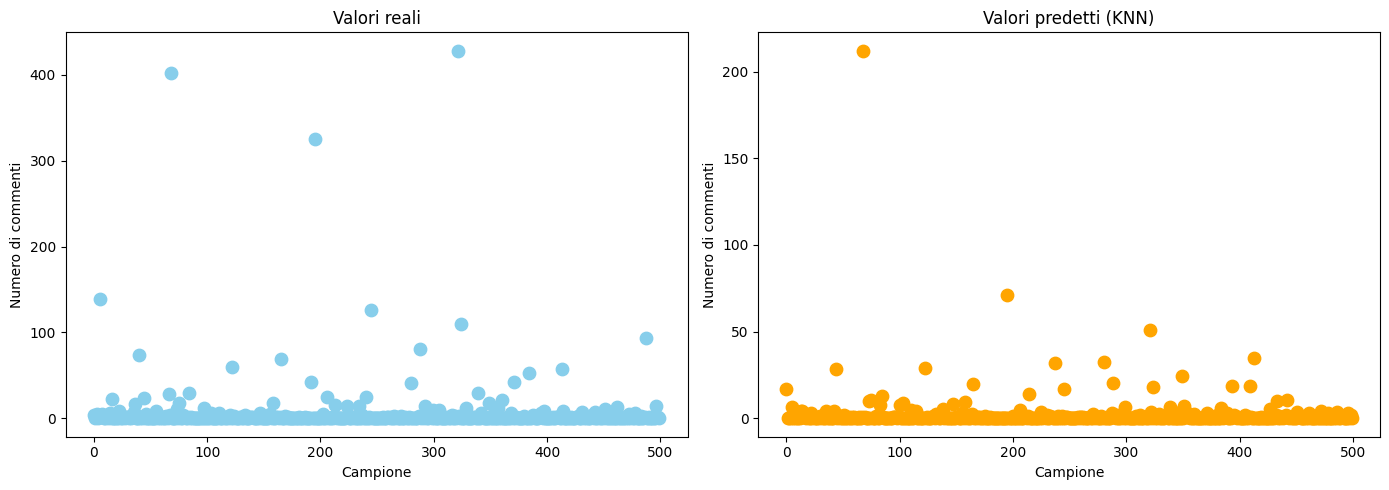

In [ ]:
# Seleziono un campione da visualizzare (primi 500 valori)
n_plot = 500
y_true_plot = all_y_true[:n_plot]
y_pred_plot = all_y_pred[:n_plot]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Grafico valori reali
axs[0].scatter(range(n_plot), y_true_plot, color='skyblue', s=80)
axs[0].set_title("Valori reali")
axs[0].set_xlabel("Campione")
axs[0].set_ylabel("Numero di commenti")

# Grafico valori predetti dal KNN
axs[1].scatter(range(n_plot), y_pred_plot, color='orange', s=80)
axs[1].set_title("Valori predetti (KNN)")
axs[1].set_xlabel("Campione")
axs[1].set_ylabel("Numero di commenti")

plt.tight_layout()
plt.show()


ELASTIC-NET

In [ ]:
#Pipeline Enet (Scaler + feature selection + model)
pipeline_enet = Pipeline([
    ("scaler", RobustScaler(quantile_range=(10, 90))),
    ("selector", SelectKBest(score_func=f_regression, k=80)),
    ("model", ElasticNet(max_iter=5000, random_state=42))
])


param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

#ottimizzazione iperparametrica
grid = GridSearchCV(
    pipeline_enet,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train) #addestramento modello

best_enet = grid.best_estimator_

print("Migliori iperparametri:", grid.best_params_)

Migliori iperparametri: {'model__alpha': 1, 'model__l1_ratio': 0.9}


In [ ]:
#valutazione
mae_boost, rmse_boost, r2_boost, all_y_true, all_y_pred = evaluate_model_filewise(
    best_enet, "Elastic Net"
)


===== VALUTAZIONE Elastic Net =====
blogData_test-2012.02.01.00_00.csv | MAE=7.061 | RMSE=22.314 | R2=0.688
blogData_test-2012.02.02.00_00.csv | MAE=5.575 | RMSE=17.053 | R2=0.701
blogData_test-2012.02.03.00_00.csv | MAE=6.633 | RMSE=28.316 | R2=0.535
blogData_test-2012.02.04.00_00.csv | MAE=3.970 | RMSE=9.014 | R2=-0.066
blogData_test-2012.02.05.00_00.csv | MAE=3.781 | RMSE=12.026 | R2=0.858
blogData_test-2012.02.06.00_00.csv | MAE=4.244 | RMSE=13.146 | R2=0.745
blogData_test-2012.02.07.00_00.csv | MAE=5.690 | RMSE=16.988 | R2=-0.738
blogData_test-2012.02.08.00_00.csv | MAE=7.659 | RMSE=28.969 | R2=0.397
blogData_test-2012.02.09.00_00.csv | MAE=5.898 | RMSE=24.249 | R2=0.436
blogData_test-2012.02.10.00_00.csv | MAE=5.025 | RMSE=16.311 | R2=0.670
blogData_test-2012.02.11.00_00.csv | MAE=3.273 | RMSE=5.654 | R2=-0.865
blogData_test-2012.02.12.00_00.csv | MAE=2.149 | RMSE=2.995 | R2=-0.482
blogData_test-2012.02.13.00_00.csv | MAE=4.509 | RMSE=16.369 | R2=0.028
blogData_test-2012.02.14.0

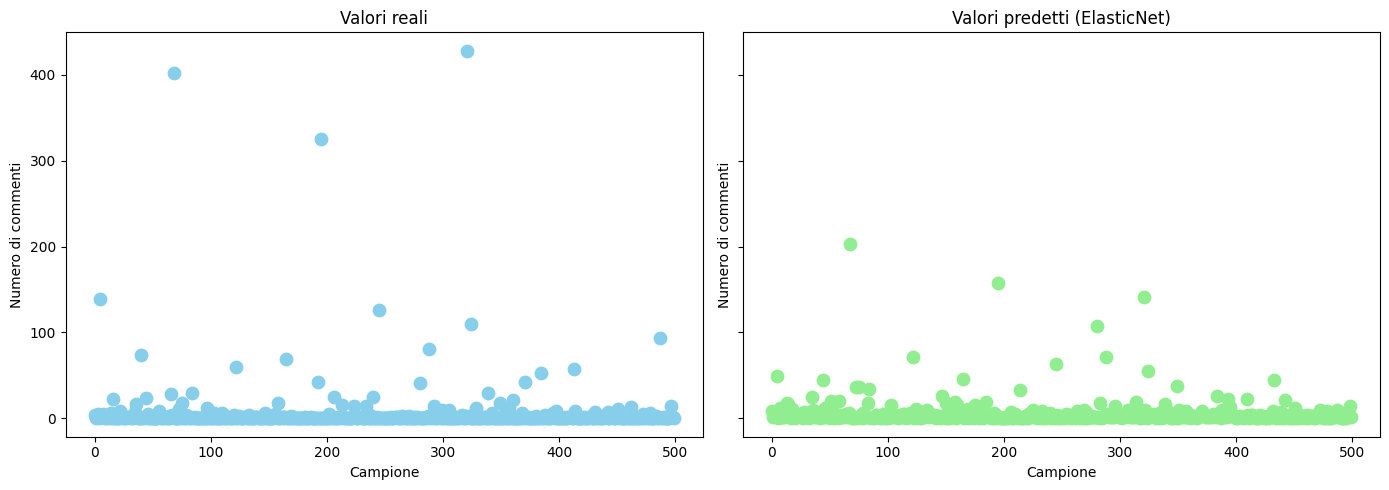

In [ ]:
# Seleziono un campione per il grafico
n_plot = 500
y_true_plot = all_y_true[:n_plot]
y_pred_plot = all_y_pred[:n_plot]

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True )

# Grafico dei valori reali
axs[0].scatter(range(n_plot), y_true_plot, color='skyblue', s=80)
axs[0].set_title("Valori reali")
axs[0].set_xlabel("Campione")
axs[0].set_ylabel("Numero di commenti")

# Grafico dei valori predetti
axs[1].scatter(range(n_plot), y_pred_plot, color='lightgreen', s=80)
axs[1].set_title("Valori predetti (ElasticNet)")
axs[1].set_xlabel("Campione")
axs[1].set_ylabel("Numero di commenti")

plt.tight_layout()
plt.show()


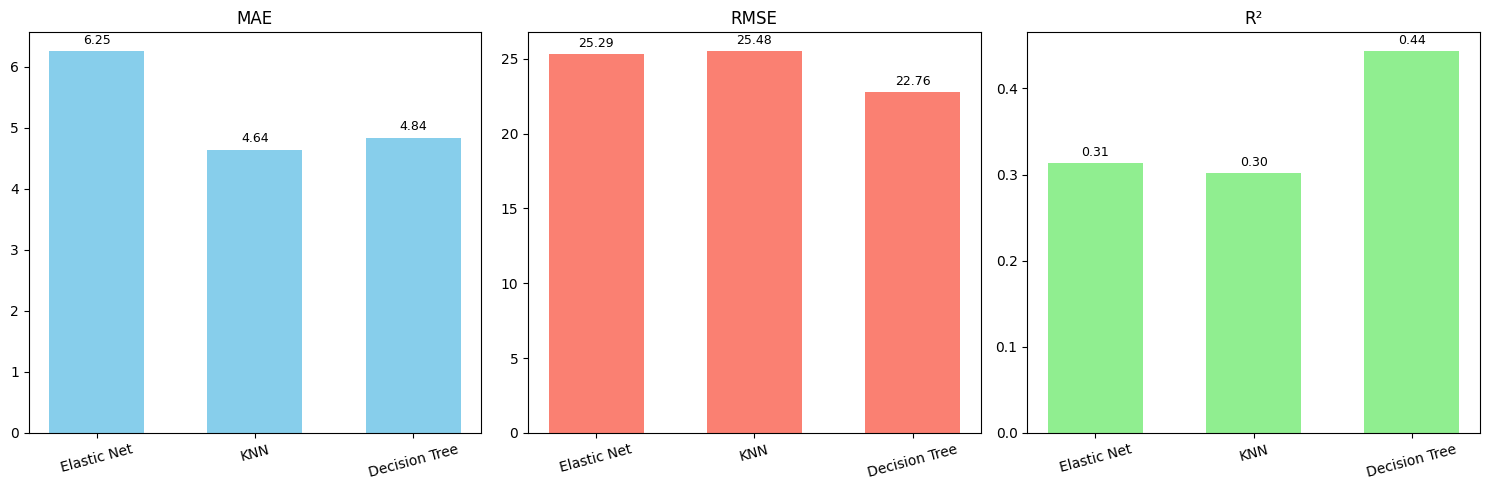

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Modelli
models = ['Elastic Net', 'KNN', 'Decision Tree']

# Metriche
mae = [6.255, 4.645, 4.841]
rmse = [25.287, 25.485, 22.763]
r2 = [0.313, 0.302, 0.443]

x = np.arange(len(models))  # posizione dei modelli
width = 0.6  # larghezza barre

# Colori per ciascuna metrica
colors = ['skyblue', 'salmon', 'lightgreen']

fig, axs = plt.subplots(1, 3, figsize=(15,5))

# Funzione per disegnare barre con valori sopra
def draw_bars(ax, values, title, color):
    bars = ax.bar(x, values, width, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_title(title)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

draw_bars(axs[0], mae, 'MAE', colors[0])
draw_bars(axs[1], rmse, 'RMSE', colors[1])
draw_bars(axs[2], r2, 'R²', colors[2])

plt.tight_layout()
plt.show()


PILATO

CONFIGURAZIONI MLP

In [ ]:
# Disabilita gli avvisi UserWarning per mantenere l'output pulito
warnings.filterwarnings("ignore", category=UserWarning)
# 1. SETUP E CARICAMENTO TRAIN
# Trasformazione logaritmica del target: uso log(1+y) per normalizzare
y_train_log = np.log1p(y_train)

In [ ]:
# 2. Definizione Pipeline (Feature Selection + Scaling)
preprocess = Pipeline([
    ('selector', SelectKBest(score_func=f_regression, k=100)), # Seleziono le 100 feature migliori
    ('scaler', StandardScaler())                               # Standardizzazione
])

In [ ]:
# 3. TRASFORMAZIONE DATI
# Esecuzione della Pipeline: con fit_trasform calcolo i parametri (medie, deviazioni, score)
X_train_final = preprocess.fit_transform(X_train, y_train_log)

print(f"Trasformazione completata. Nuova forma dati Train: {X_train_final.shape}")

Trasformazione completata. Nuova forma dati Train: (49203, 100)


In [ ]:
# 4. FUNZIONE CARICAMENTO TEST
def load_test_file(path):

    df = pd.read_csv(path, header=None)

    #Separazione delle feature e del targhet
    X_raw = df.iloc[:, :-1].values.astype("float32")
    y_real = df.iloc[:, -1].values.astype("float32")

    # Trasformazione coerente usando la pipeline fittata sul train
    X_transformed = preprocess.transform(X_raw)
    return X_transformed, y_real

In [ ]:
# 4. SETUP RETE E EVALUATION
ES = keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)
# 5. COSTRUZIONE MODELLO MLP(Multi-Layer Perceptron)
def build_mlp(input_dim, layers_list, dropout_rate, learning_rate):

    #Inizializzo il modello sequenziale strato dopo strato
    model = keras.Sequential([layers.Input(shape=(input_dim,))])

    for units in layers_list:
        #Funzione di attivazione ReLU
        model.add(layers.Dense(units, activation="relu"))

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='linear'))
    #Compilo usando Adam e MSE come funzione di costo
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
    return model

In [ ]:
# 6. FUNZIONE DI VALUTAZIONE (Analisi file per file)
def evaluate_model_real(model, test_files_paths, name):
    y_true_all, y_pred_all = [], []

    print(f"\nReport dettagliato per {name}:")
    print(f"{'FILE TEST':<35} | {'MAE':<8} | {'RMSE':<8} | {'R2 REAL':<8}")
    print("-" * 95)

    for f_path in test_files_paths:
        # Caricamento e trasformazione atomica del singolo file
        X_transformed, y_real = load_test_file(f_path)

        # Predizione e conversione in scala reale (inversa del log)
        p_log = model.predict(X_transformed, verbose=0).ravel()
        p_real = np.expm1(np.clip(p_log, 0, 6))

        # Calcolo metriche per il singolo file
        mae_f = mean_absolute_error(y_real, p_real)
        rmse_f = np.sqrt(mean_squared_error(y_real, p_real))
        r2_f = r2_score(y_real, p_real)

        print(f"{os.path.basename(f_path):<35} | {mae_f:<8.2f} | {rmse_f:<8.2f} | {r2_f:<8.4f}")

        #Accumulo i risultati per calcolare la performance media
        y_true_all.extend(y_real)
        y_pred_all.extend(p_real)

    # Calcolo le metriche globali aggregate
    mae_tot = mean_absolute_error(y_true_all, y_pred_all)
    rmse_tot = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    r2_tot = r2_score(y_true_all, y_pred_all)

    print("-" * 95)
    print(f"--- REPORT FINALE GLOBALE: {name} ---")
    print(f"MAE Totale: {mae_tot:.4f} | RMSE Totale: {rmse_tot:.4f} | R2 Totale: {r2_tot:.4f}")

    return mae_tot, rmse_tot, r2_tot, np.array(y_true_all), np.array(y_pred_all)

1. Configurazione MLP SMALL

In [ ]:
# --- 1. CONFIGURAZIONE MLP_SMALL ---
print(f"Training di MLP_Small in corso...")

# Creazione del modello
model_small = build_mlp(X_train_final.shape[1], [64], 0.1, 1e-3)

#Addestramento (Fit)
model_small.fit(X_train_final, y_train_log, validation_split=0.2, epochs=100, batch_size=512, callbacks=[ES], verbose=0)

# Chiamata alla funzione di valutazione: passo il modello addestrato e i file di test
mae_small, rmse_small, r2_small, y_true_small, y_pred_small = evaluate_model_real(
    model_small,     # 1° parametro: model
    test_files,      # 2° parametro: test_files_paths
    "MLP_Small"      # 3° parametro: name
)

Training di MLP_Small in corso...

Report dettagliato per MLP_Small:
FILE TEST                           | MAE      | RMSE     | R2 REAL 
-----------------------------------------------------------------------------------------------
blogData_test-2012.02.01.00_00.csv  | 6.65     | 34.94    | 0.2361  
blogData_test-2012.02.02.00_00.csv  | 4.99     | 26.57    | 0.2732  
blogData_test-2012.02.03.00_00.csv  | 5.52     | 35.23    | 0.2794  
blogData_test-2012.02.04.00_00.csv  | 2.30     | 7.78     | 0.2066  
blogData_test-2012.02.05.00_00.csv  | 4.29     | 24.16    | 0.4258  
blogData_test-2012.02.06.00_00.csv  | 4.17     | 24.50    | 0.1162  
blogData_test-2012.02.07.00_00.csv  | 3.15     | 11.91    | 0.1463  
blogData_test-2012.02.08.00_00.csv  | 6.61     | 33.18    | 0.2087  
blogData_test-2012.02.09.00_00.csv  | 4.45     | 30.09    | 0.1315  
blogData_test-2012.02.10.00_00.csv  | 3.96     | 24.65    | 0.2457  
blogData_test-2012.02.11.00_00.csv  | 1.22     | 2.66     | 0.5864  
blogDat


--- REPORT FINALE GLOBALE: MLP_Small ---
MAE Reale:      5.0191
RMSE Reale:     29.9317
R2 Log:       0.0369


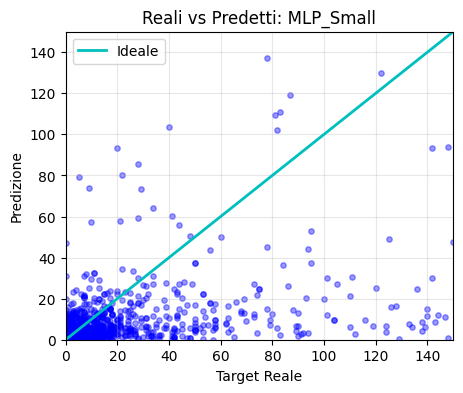

In [ ]:
print(f"\n--- REPORT FINALE GLOBALE: MLP_Small ---")
print(f"MAE Reale:      {mae_small:.4f}")
print(f"RMSE Reale:     {rmse_small:.4f}")
print(f"R2 Log:       {r2_small:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_true_small, y_pred_small, alpha=0.4, s=15, color='blue')
plt.plot([0, 150], [0, 150], 'c', lw=2, label="Ideale")
plt.title(f"Reali vs Predetti: MLP_Small")
plt.xlabel("Target Reale"); plt.ylabel("Predizione")
plt.xlim([0, 150]); plt.ylim([0, 150]); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()

2. Configurazione MLP MEDIUM

In [ ]:
print(f"Training di MLP_Medium in corso...")
# Creazione del modello
model_medium = build_mlp(X_train_final.shape[1], [128, 128], 0.2, 5e-4)

# Addestramento (Fit)
model_medium.fit(X_train_final, y_train_log, validation_split=0.2, epochs=100, batch_size=512, callbacks=[ES], verbose=0)

mae_med, rmse_med, r2_med, y_true_med, y_pred_med = evaluate_model_real(
    model_medium,
    test_files,
    "MLP_Medium")

Training di MLP_Medium in corso...

Report dettagliato per MLP_Medium:
FILE TEST                           | MAE      | RMSE     | R2 REAL 
-----------------------------------------------------------------------------------------------
blogData_test-2012.02.01.00_00.csv  | 6.57     | 33.53    | 0.2963  
blogData_test-2012.02.02.00_00.csv  | 5.51     | 29.07    | 0.1301  
blogData_test-2012.02.03.00_00.csv  | 6.10     | 39.31    | 0.1030  
blogData_test-2012.02.04.00_00.csv  | 2.32     | 7.71     | 0.2194  
blogData_test-2012.02.05.00_00.csv  | 4.32     | 24.77    | 0.3963  
blogData_test-2012.02.06.00_00.csv  | 4.33     | 24.93    | 0.0845  
blogData_test-2012.02.07.00_00.csv  | 3.62     | 12.89    | -0.0003 
blogData_test-2012.02.08.00_00.csv  | 6.61     | 32.95    | 0.2199  
blogData_test-2012.02.09.00_00.csv  | 4.58     | 29.94    | 0.1399  
blogData_test-2012.02.10.00_00.csv  | 4.18     | 25.84    | 0.1709  
blogData_test-2012.02.11.00_00.csv  | 1.20     | 2.85     | 0.5272  
blogD


--- REPORT FINALE GLOBALE: MLP_Medium ---
MAE Reale:      4.9762
RMSE Reale:     28.7249
R2 Log:       0.1130


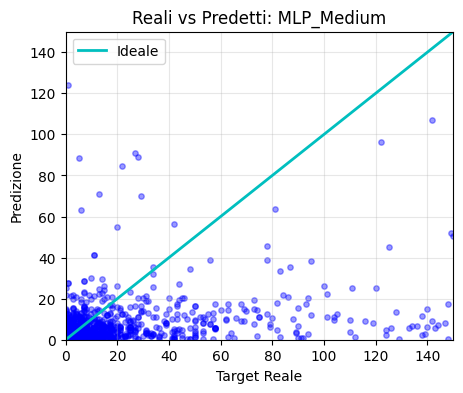

In [ ]:
print(f"\n--- REPORT FINALE GLOBALE: MLP_Medium ---")
print(f"MAE Reale:      {mae_med:.4f}")
print(f"RMSE Reale:     {rmse_med:.4f}")
print(f"R2 Log:       {r2_med:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_true_med, y_pred_med, alpha=0.4, s=15, color='blue')
plt.plot([0, 150], [0, 150], 'c', lw=2, label="Ideale")
plt.title(f"Reali vs Predetti: MLP_Medium")
plt.xlabel("Target Reale"); plt.ylabel("Predizione")
plt.xlim([0, 150]); plt.ylim([0, 150]); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()

3. Configurazione MLP DEEP

In [ ]:
# --- 3. MLP_DEEP ---
print("\nTraining MLP_Deep...")

# Costruzione del modello
model_deep = build_mlp(X_train_final.shape[1], [256, 128, 64], 0.2, 5e-4)

# Addestramento (Fit)
model_deep.fit(X_train_final, y_train_log, validation_split=0.2, epochs=100, batch_size=512, callbacks=[ES], verbose=0)
mae_deep, rmse_deep, r2_deep, y_true_deep, y_pred_deep = evaluate_model_real(
    model_deep,
    test_files,
    "MLP_Deep")


Training MLP_Deep...

Report dettagliato per MLP_Deep:
FILE TEST                           | MAE      | RMSE     | R2 REAL 
-----------------------------------------------------------------------------------------------
blogData_test-2012.02.01.00_00.csv  | 6.75     | 35.70    | 0.2022  
blogData_test-2012.02.02.00_00.csv  | 5.63     | 29.68    | 0.0928  
blogData_test-2012.02.03.00_00.csv  | 6.00     | 39.06    | 0.1142  
blogData_test-2012.02.04.00_00.csv  | 2.30     | 7.80     | 0.2022  
blogData_test-2012.02.05.00_00.csv  | 4.32     | 25.26    | 0.3720  
blogData_test-2012.02.06.00_00.csv  | 4.38     | 24.63    | 0.1063  
blogData_test-2012.02.07.00_00.csv  | 3.49     | 12.39    | 0.0749  
blogData_test-2012.02.08.00_00.csv  | 6.70     | 33.18    | 0.2087  
blogData_test-2012.02.09.00_00.csv  | 4.56     | 29.94    | 0.1398  
blogData_test-2012.02.10.00_00.csv  | 4.20     | 24.88    | 0.2314  
blogData_test-2012.02.11.00_00.csv  | 1.15     | 2.69     | 0.5764  
blogData_test-2012.0


--- REPORT FINALE GLOBALE: MLP_Deep ---
MAE Reale:      4.9566
RMSE Reale:     28.7846
R2 Log:       0.1093


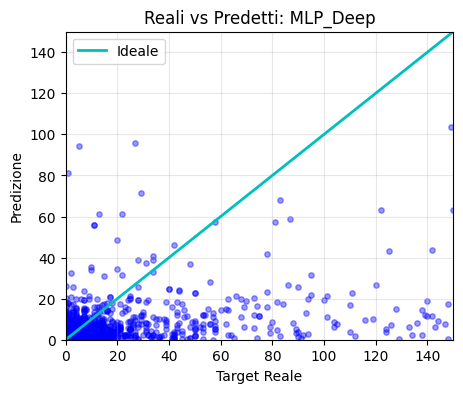

In [ ]:
print(f"\n--- REPORT FINALE GLOBALE: MLP_Deep ---")
print(f"MAE Reale:      {mae_deep:.4f}")
print(f"RMSE Reale:     {rmse_deep:.4f}")
print(f"R2 Log:       {r2_deep:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_true_deep, y_pred_deep, alpha=0.4, s=15, color='blue')
plt.plot([0, 150], [0, 150], 'c', lw=2, label="Ideale")
plt.title(f"Reali vs Predetti: MLP_Deep")
plt.xlabel("Target Reale"); plt.ylabel("Predizione")
plt.xlim([0, 150]); plt.ylim([0, 150]); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()

4. Configurazione MLP WIDE

In [ ]:
# --- CONFIGURAZIONE MLP_WIDE ---
print(f"Training di MLP_Wide in corso...")

# Costruzione del modello
model_wide = build_mlp(X_train_final.shape[1], [512], 0.3, 1e-4)

#Addestramento (Fit)
model_wide.fit(X_train_final, y_train_log, validation_split=0.2, epochs=100, batch_size=512, callbacks=[ES], verbose=0)
mae_wide, rmse_wide, r2_wide, y_true_wide, y_pred_wide = evaluate_model_real(
    model_wide,
    test_files,
    "MLP_Wide")

Training di MLP_Wide in corso...

Report dettagliato per MLP_Wide:
FILE TEST                           | MAE      | RMSE     | R2 REAL 
-----------------------------------------------------------------------------------------------
blogData_test-2012.02.01.00_00.csv  | 5.67     | 26.68    | 0.5545  
blogData_test-2012.02.02.00_00.csv  | 5.13     | 26.36    | 0.2846  
blogData_test-2012.02.03.00_00.csv  | 5.63     | 37.28    | 0.1932  
blogData_test-2012.02.04.00_00.csv  | 2.41     | 8.01     | 0.1576  
blogData_test-2012.02.05.00_00.csv  | 3.82     | 20.36    | 0.5922  
blogData_test-2012.02.06.00_00.csv  | 4.14     | 23.51    | 0.1857  
blogData_test-2012.02.07.00_00.csv  | 3.62     | 13.62    | -0.1169 
blogData_test-2012.02.08.00_00.csv  | 5.99     | 29.74    | 0.3646  
blogData_test-2012.02.09.00_00.csv  | 4.42     | 29.80    | 0.1480  
blogData_test-2012.02.10.00_00.csv  | 4.12     | 24.52    | 0.2533  
blogData_test-2012.02.11.00_00.csv  | 1.16     | 2.66     | 0.5884  
blogData_


--- REPORT FINALE GLOBALE: MLP_Wide ---
MAE Reale:      5.0433
RMSE Reale:     29.6369
R2 Log:       0.0558


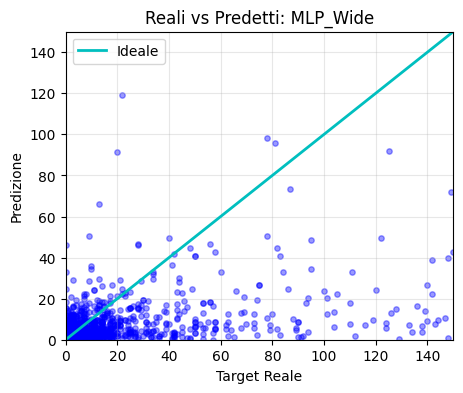

In [ ]:
print(f"\n--- REPORT FINALE GLOBALE: MLP_Wide ---")
print(f"MAE Reale:      {mae_wide:.4f}")
print(f"RMSE Reale:     {rmse_wide:.4f}")
print(f"R2 Log:       {r2_wide:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_true_wide, y_pred_wide, alpha=0.4, s=15, color='blue')
plt.plot([0, 150], [0, 150], 'c', lw=2, label="Ideale")
plt.title(f"Reali vs Predetti: MLP_Wide")
plt.xlabel("Target Reale"); plt.ylabel("Predizione")
plt.xlim([0, 150]); plt.ylim([0, 150]); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()

5. Configurazione MLP REGULAR

In [ ]:
# --- CONFIGURAZIONE MLP_REG ---
print(f"Training di MLP_Reg in corso...")

# Costruzione del modello
model_reg = build_mlp(X_train_final.shape[1], [256, 256], 0.4, 5e-4)

# Addestramento (Fit)
model_reg.fit(X_train_final, y_train_log, validation_split=0.2, epochs=100, batch_size=512, callbacks=[ES], verbose=0)
mae_reg, rmse_reg, r2_reg, y_true_reg, y_pred_reg = evaluate_model_real(
    model_reg,
    test_files,
    "MLP_Reg")

Training di MLP_Reg in corso...

Report dettagliato per MLP_Reg:
FILE TEST                           | MAE      | RMSE     | R2 REAL 
-----------------------------------------------------------------------------------------------
blogData_test-2012.02.01.00_00.csv  | 6.06     | 30.60    | 0.4138  
blogData_test-2012.02.02.00_00.csv  | 5.56     | 29.20    | 0.1221  
blogData_test-2012.02.03.00_00.csv  | 6.05     | 38.17    | 0.1542  
blogData_test-2012.02.04.00_00.csv  | 2.38     | 8.15     | 0.1283  
blogData_test-2012.02.05.00_00.csv  | 3.96     | 21.47    | 0.5462  
blogData_test-2012.02.06.00_00.csv  | 4.39     | 24.78    | 0.0958  
blogData_test-2012.02.07.00_00.csv  | 3.84     | 14.37    | -0.2433 
blogData_test-2012.02.08.00_00.csv  | 6.02     | 29.76    | 0.3637  
blogData_test-2012.02.09.00_00.csv  | 4.51     | 29.40    | 0.1704  
blogData_test-2012.02.10.00_00.csv  | 3.62     | 23.12    | 0.3363  
blogData_test-2012.02.11.00_00.csv  | 1.12     | 2.64     | 0.5934  
blogData_te


--- REPORT FINALE GLOBALE: MLP_Reg ---
MAE Reale:      4.5670
RMSE Reale:     26.2933
R2 Log:       0.2568


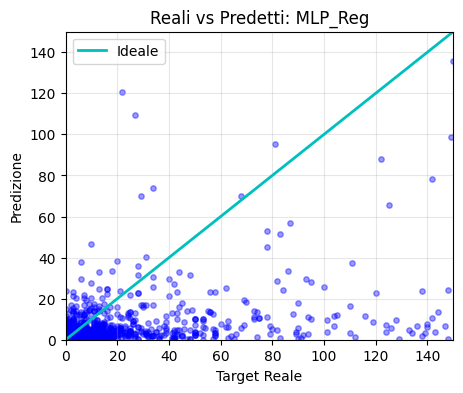

In [ ]:
print(f"\n--- REPORT FINALE GLOBALE: MLP_Reg ---")
print(f"MAE Reale:      {mae_reg:.4f}")
print(f"RMSE Reale:     {rmse_reg:.4f}")
print(f"R2 Log:       {r2_reg:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_true_reg, y_pred_reg, alpha=0.4, s=15, color='blue')
plt.plot([0, 150], [0, 150], 'c', lw=2, label="Ideale")
plt.title(f"Reali vs Predetti: MLP_Reg")
plt.xlabel("Target Reale"); plt.ylabel("Predizione")
plt.xlim([0, 150]); plt.ylim([0, 150]); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()

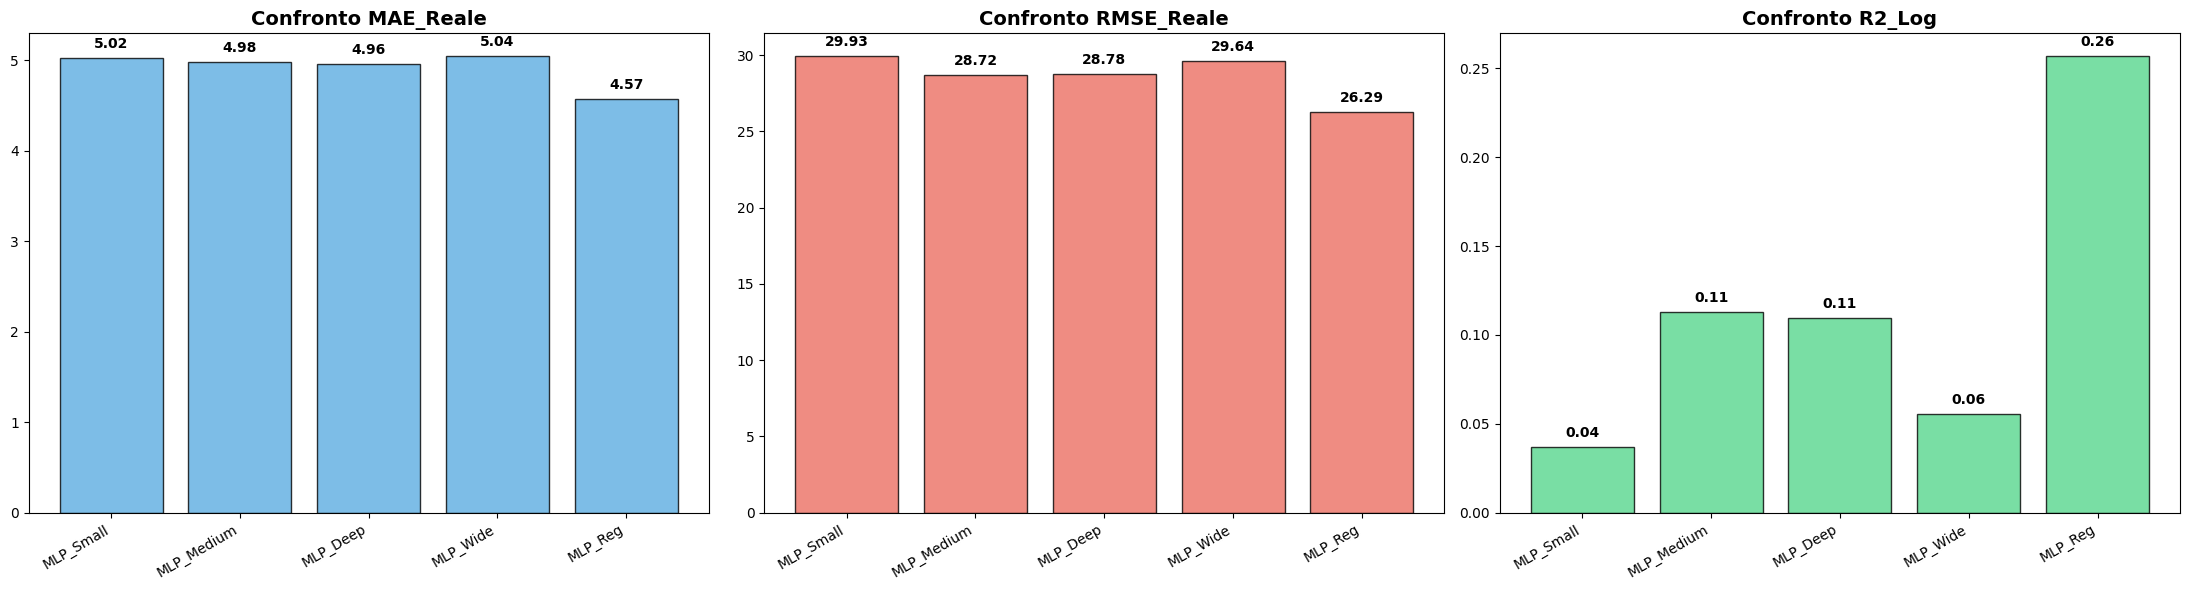


--- CLASSIFICA FINALE MODELLI ---
Configurazione  MAE_Reale  RMSE_Reale   R2_Log
       MLP_Reg   4.567047   26.293324 0.256819
      MLP_Deep   4.956552   28.784611 0.109315
    MLP_Medium   4.976174   28.724874 0.113008
     MLP_Small   5.019124   29.931690 0.036912
      MLP_Wide   5.043339   29.636892 0.055790


In [ ]:
# Creazione DataFrame per il confronto
data_summary = {
    "Configurazione": ["MLP_Small", "MLP_Medium", "MLP_Deep", "MLP_Wide", "MLP_Reg"],
    "MAE_Reale": [mae_small, mae_med, mae_deep, mae_wide, mae_reg],
    "RMSE_Reale": [rmse_small, rmse_med, rmse_deep, rmse_wide, rmse_reg],
    "R2_Log": [r2_small, r2_med, r2_deep, r2_wide, r2_reg]
}

df_final = pd.DataFrame(data_summary)

# --- GRAFICO DI CONFRONTO ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics_to_plot = ["MAE_Reale", "RMSE_Reale", "R2_Log"]
colors = ['#5dade2', '#ec7063', '#58d68d']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(df_final["Configurazione"], df_final[metric], color=colors[i], edgecolor='black', alpha=0.8)
    ax.set_title(f"Confronto {metric}", fontsize=14, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    # Inserimento dei valori numerici sopra ogni barra
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- ANALISI FINALE (Classifica) ---
print("\n--- CLASSIFICA FINALE MODELLI ---")
# Ordino per MAE (il migliore in alto)
print(df_final.sort_values(by="MAE_Reale").to_string(index=False))